<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

<Figure size 1200x800 with 0 Axes>

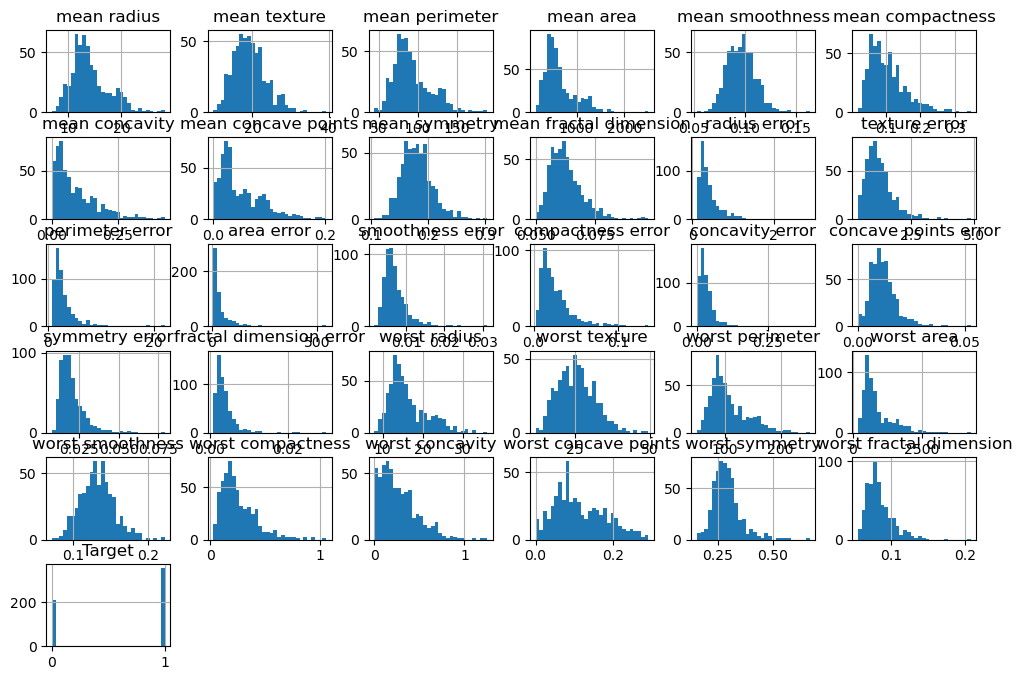

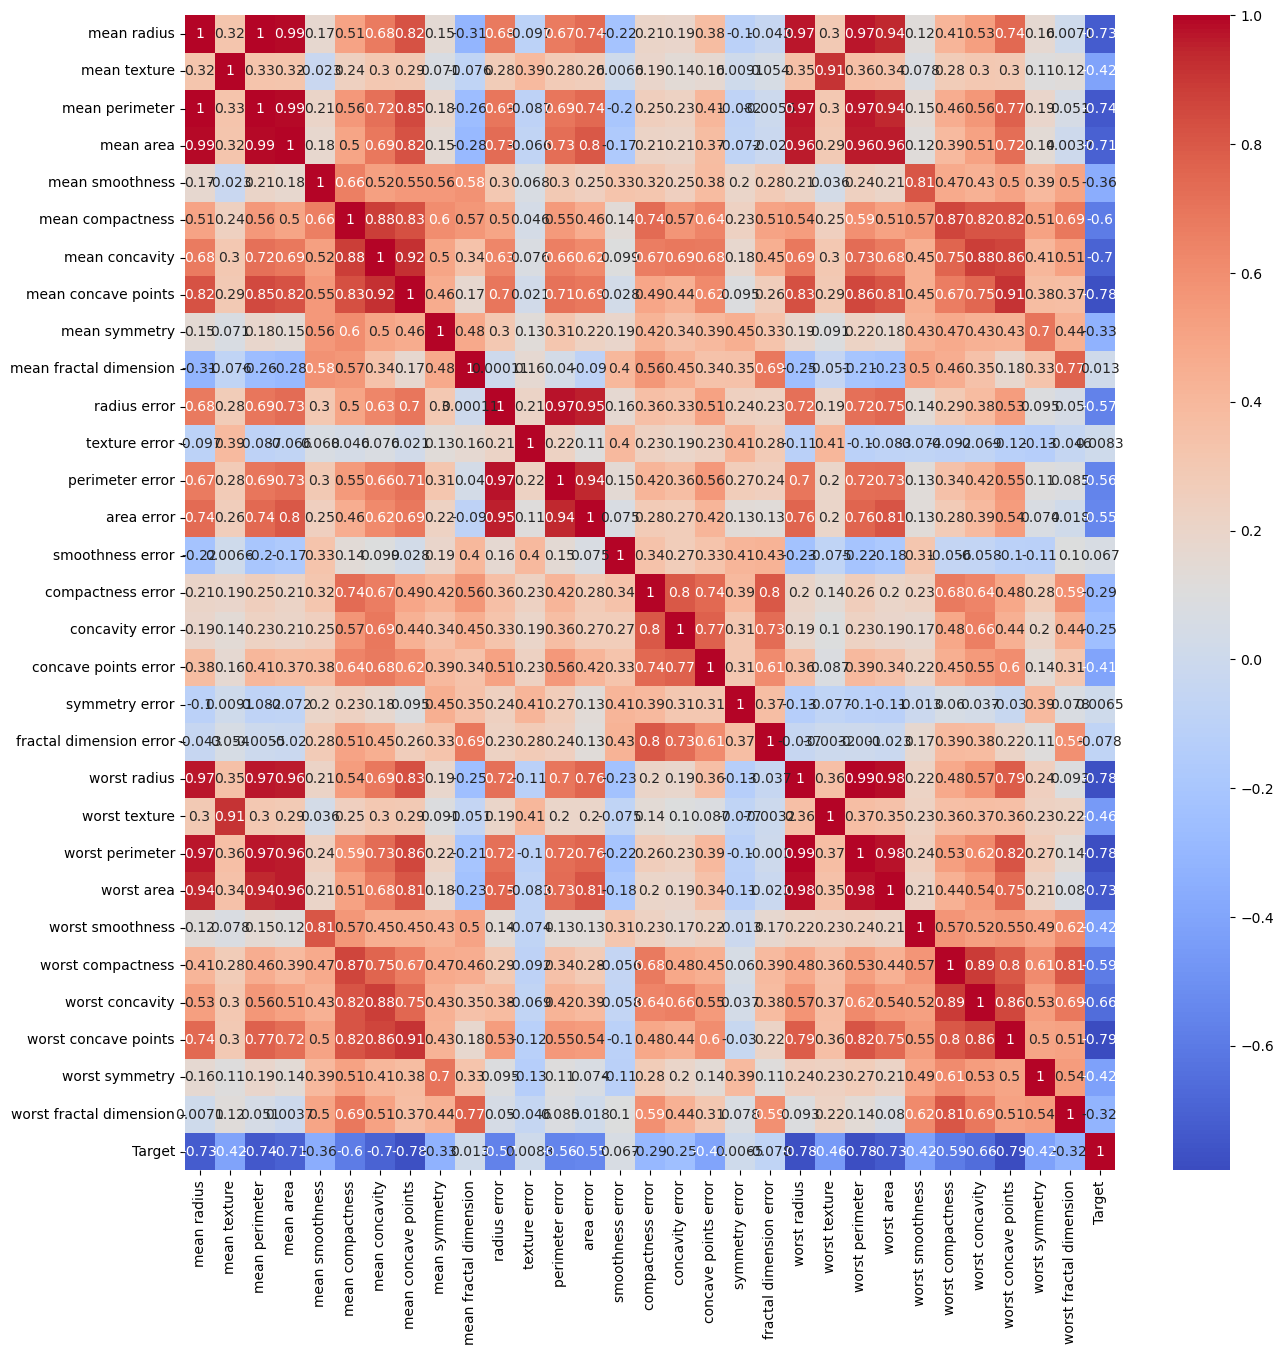

Epoch 1/50
15/15 [==============================] - 1s 19ms/step - loss: 0.6649 - accuracy: 0.4593 - val_loss: 0.5990 - val_accuracy: 0.5789
Epoch 2/50
15/15 [==============================] - 0s 7ms/step - loss: 0.5455 - accuracy: 0.7736 - val_loss: 0.5006 - val_accuracy: 0.8509
Epoch 3/50
15/15 [==============================] - 0s 6ms/step - loss: 0.4665 - accuracy: 0.8813 - val_loss: 0.4301 - val_accuracy: 0.9123
Epoch 4/50
15/15 [==============================] - 0s 7ms/step - loss: 0.4077 - accuracy: 0.9165 - val_loss: 0.3748 - val_accuracy: 0.9211
Epoch 5/50
15/15 [==============================] - 0s 5ms/step - loss: 0.3609 - accuracy: 0.9231 - val_loss: 0.3324 - val_accuracy: 0.9386
Epoch 6/50
15/15 [==============================] - 0s 6ms/step - loss: 0.3243 - accuracy: 0.9297 - val_loss: 0.2986 - val_accuracy: 0.9474
Epoch 7/50
15/15 [==============================] - 0s 7ms/step - loss: 0.2950 - accuracy: 0.9407 - val_loss: 0.2708 - val_accuracy: 0.9474
Epoch 8/50
15/15 [=

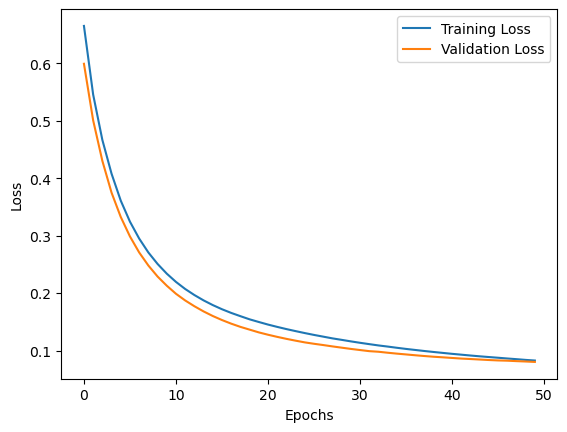

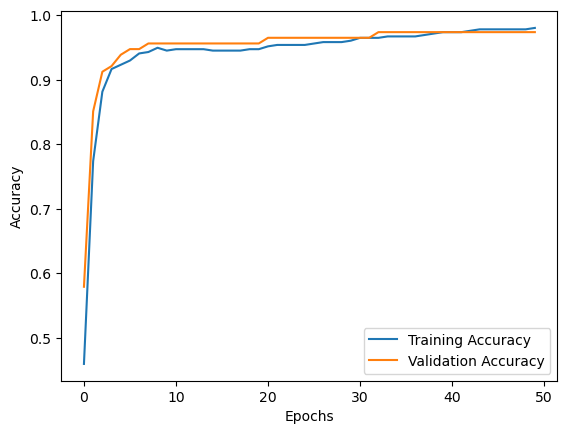

4/4 [==============================] - 0s 3ms/step - loss: 0.0803 - accuracy: 0.9737
Test Accuracy: 0.9736841917037964


In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_breast_cancer

# Load the dataset
dataset = load_breast_cancer()
X, y = dataset.data, dataset.target  # Features and target
columns = dataset.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=columns)
df['Target'] = y

# Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Check for missing values

# Visualize feature distributions
plt.figure(figsize=(12, 8))
df.hist(bins=30, figsize=(12, 8))
plt.show()

# Correlation matrix
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the ANN model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Accuracy: {accuracy}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

<Figure size 1200x800 with 0 Axes>

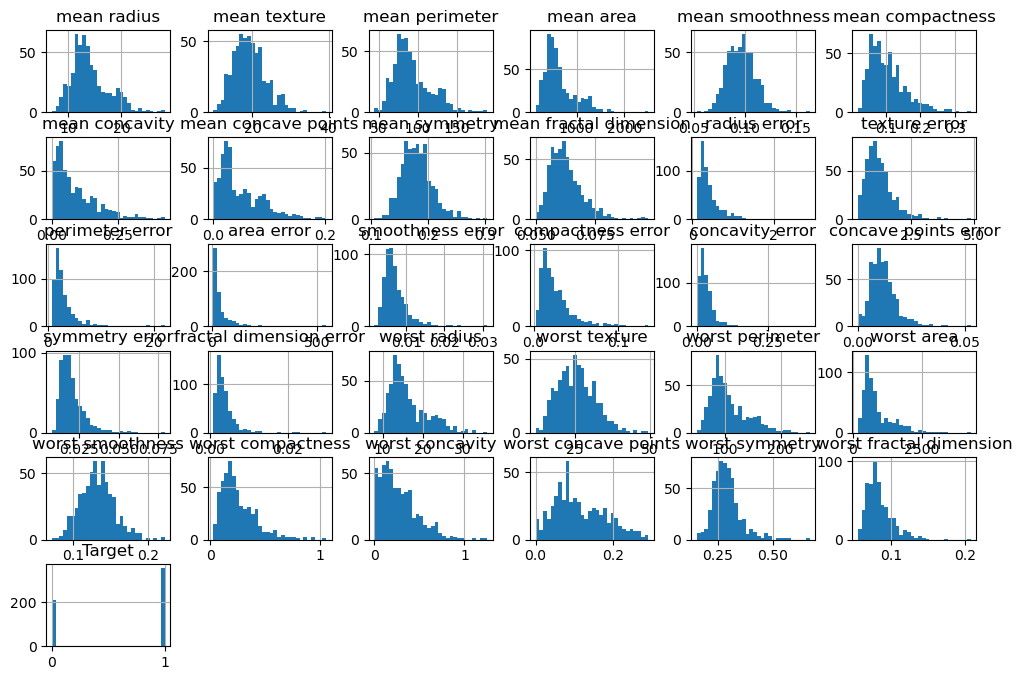

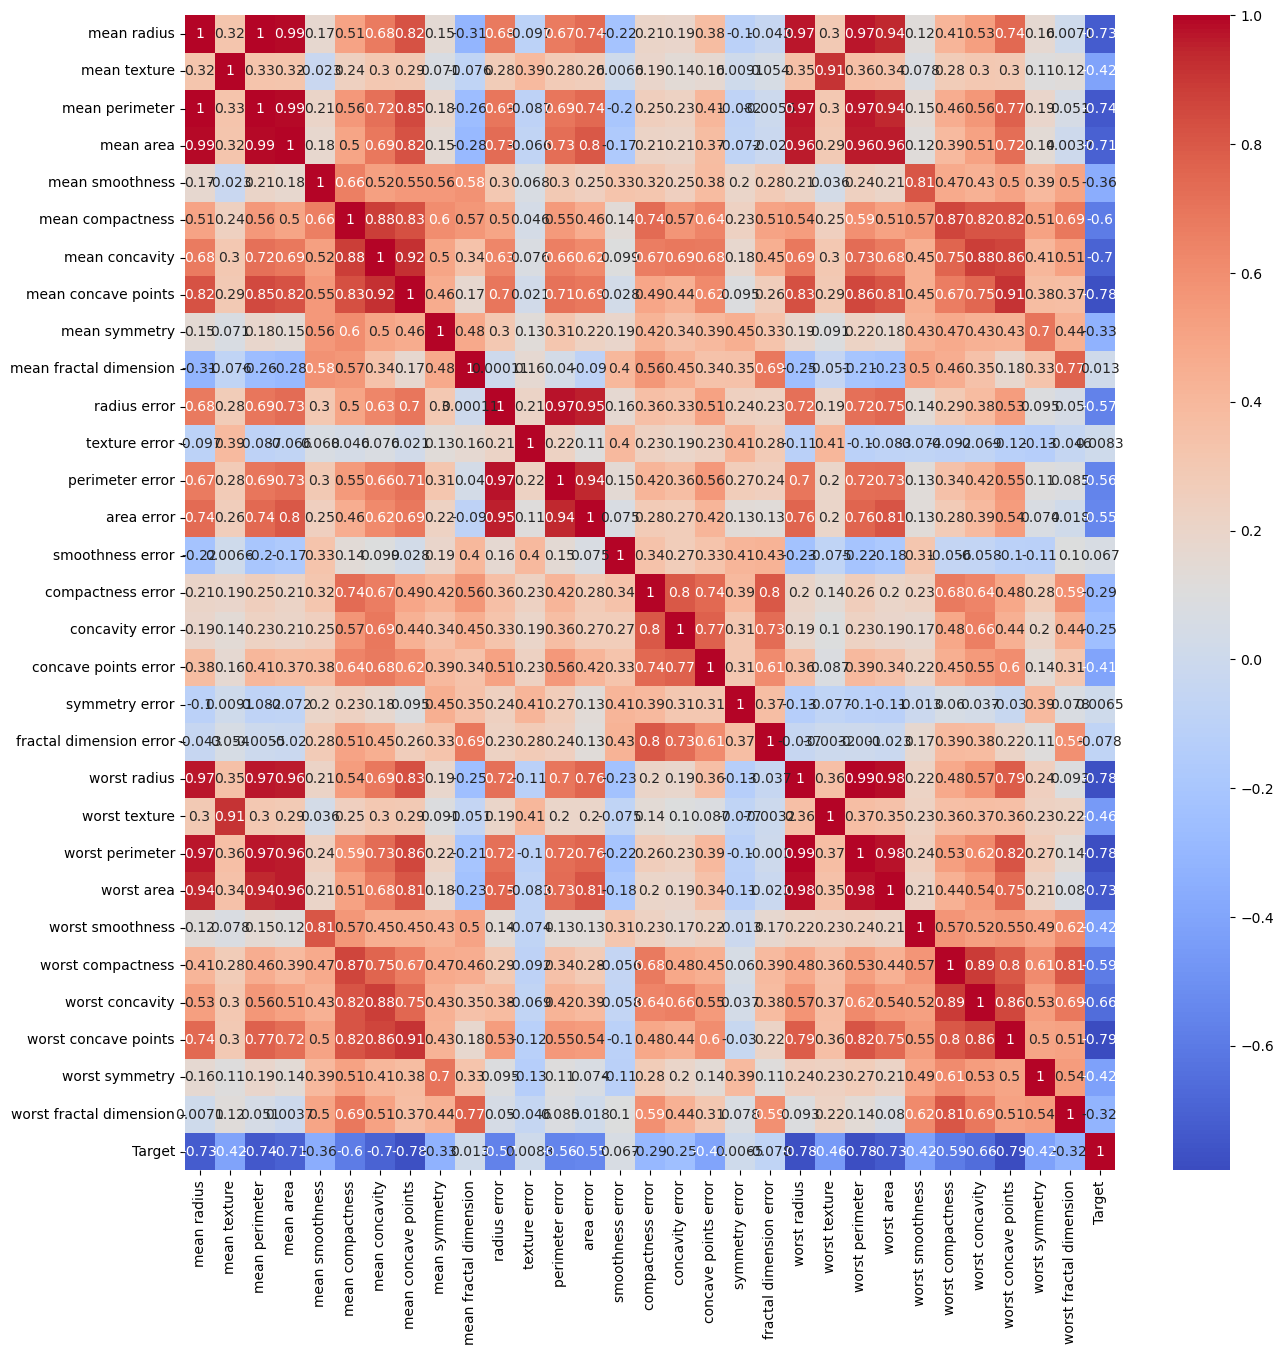

Epoch 1/50
15/15 [==============================] - 1s 22ms/step - loss: 0.6097 - accuracy: 0.6352 - val_loss: 0.3866 - val_accuracy: 0.9298
Epoch 2/50
15/15 [==============================] - 0s 7ms/step - loss: 0.3162 - accuracy: 0.9363 - val_loss: 0.2166 - val_accuracy: 0.9649
Epoch 3/50
15/15 [==============================] - 0s 7ms/step - loss: 0.1989 - accuracy: 0.9516 - val_loss: 0.1426 - val_accuracy: 0.9737
Epoch 4/50
15/15 [==============================] - 0s 11ms/step - loss: 0.1455 - accuracy: 0.9626 - val_loss: 0.1084 - val_accuracy: 0.9737
Epoch 5/50
15/15 [==============================] - 0s 7ms/step - loss: 0.1159 - accuracy: 0.9736 - val_loss: 0.0927 - val_accuracy: 0.9649
Epoch 6/50
15/15 [==============================] - 0s 5ms/step - loss: 0.0975 - accuracy: 0.9824 - val_loss: 0.0825 - val_accuracy: 0.9649
Epoch 7/50
15/15 [==============================] - 0s 5ms/step - loss: 0.0850 - accuracy: 0.9846 - val_loss: 0.0757 - val_accuracy: 0.9737
Epoch 8/50
15/15 [

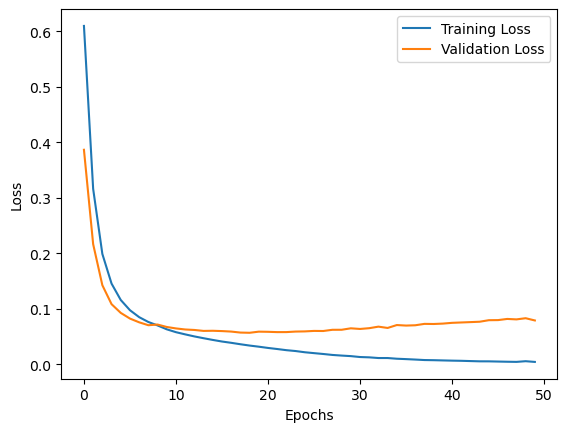

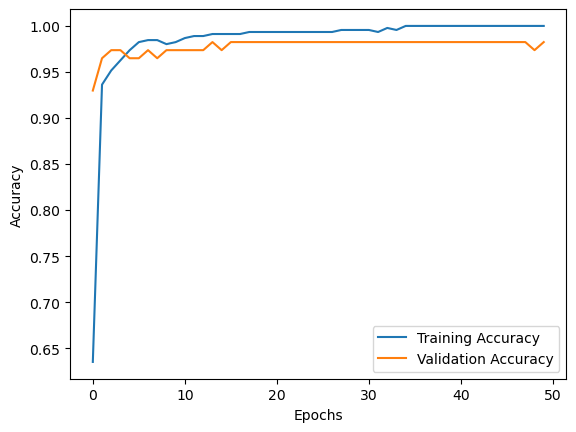

4/4 [==============================] - 0s 3ms/step - loss: 0.0791 - accuracy: 0.9825
Test Accuracy: 0.9824561476707458


In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_breast_cancer

# Load the dataset
dataset = load_breast_cancer()
X, y = dataset.data, dataset.target  # Features and target
columns = dataset.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=columns)
df['Target'] = y

# Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Check for missing values

# Visualize feature distributions
plt.figure(figsize=(12, 8))
df.hist(bins=30, figsize=(12, 8))
plt.show()

# Correlation matrix
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the ANN model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Accuracy: {accuracy}')
